In [32]:
import pandas as pd
import numpy as np

In [33]:
dataset=pd.read_csv("Placement.csv")

In [4]:
dataset.isna().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [5]:
#2. Salary column has 67 null values and the corresponding status is Not Placed
dataset[dataset["status"]=="Not Placed"][["salary","status"]]

,salary,status
3,NaN,Not Placed
5,NaN,Not Placed
6,NaN,Not Placed
9,NaN,Not Placed
12,NaN,Not Placed
...,...,...
198,NaN,Not Placed
201,NaN,Not Placed
206,NaN,Not Placed
208,NaN,Not Placed


In [6]:
#1. All the not placed rows are having salary as null values so replacing those with 0 will be a good choice
dataset["salary"].fillna(0,inplace=True)

C:\Users\Dayana\AppData\Local\Temp\ipykernel_6760\73236472.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset["salary"].fillna(0,inplace=True)


In [7]:
dataset.isna().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [8]:
#3 Find the reason for non placement from the dataset?
dataset[dataset["status"]=="Not Placed"]

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
3,4,M,56.0,Central,52.0,Central,Science,52.00,Sci&Tech,No,66.00,Mkt&HR,59.43,Not Placed,0.0
5,6,M,55.0,Others,49.8,Others,Science,67.25,Sci&Tech,Yes,55.00,Mkt&Fin,51.58,Not Placed,0.0
6,7,F,46.0,Others,49.2,Others,Commerce,79.00,Comm&Mgmt,No,74.28,Mkt&Fin,53.29,Not Placed,0.0
9,10,M,58.0,Central,70.0,Central,Commerce,61.00,Comm&Mgmt,No,54.00,Mkt&Fin,52.21,Not Placed,0.0
12,13,F,47.0,Central,55.0,Others,Science,65.00,Comm&Mgmt,No,62.00,Mkt&HR,65.04,Not Placed,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,199,F,67.0,Central,70.0,Central,Commerce,65.00,Others,No,88.00,Mkt&HR,71.96,Not Placed,0.0
201,202,M,54.2,Central,63.0,Others,Science,58.00,Comm&Mgmt,No,79.00,Mkt&HR,58.44,Not Placed,0.0
206,207,M,41.0,Central,42.0,Central,Science,60.00,Comm&Mgmt,No,97.00,Mkt&Fin,53.39,Not Placed,0.0
208,209,F,43.0,Central,60.0,Others,Science,65.00,Comm&Mgmt,No,92.66,Mkt&HR,62.92,Not Placed,0.0


In [9]:
#4. What kind of relation between salary and mba_p and salary?
dataset[["mba_p","salary"]].corr()

,mba_p,salary
mba_p,1.000000,0.139823
salary,0.139823,1.000000


In [10]:
#There is almost 0 correlation between salary and mba_p

In [11]:
dataset[["salary","salary"]].cov()

,salary,salary
salary,2.395714e+10,2.395714e+10
salary,2.395714e+10,2.395714e+10


In [12]:
#5. Which specialization is getting minimum salary?
dataset[dataset["status"]=="Placed"]["salary"].min()
dataset[dataset["salary"]==200000]["specialisation"]

1      Mkt&Fin
15     Mkt&Fin
44     Mkt&Fin
50      Mkt&HR
107     Mkt&HR
135     Mkt&HR
Name: specialisation, dtype: object

In [13]:
#MKT&HR and MKT&Fin are getting the minimum salary

In [14]:
#6. How many of them getting above 500000 salary?
dataset[dataset["salary"]>500000].count()

sl_no             3
gender            3
ssc_p             3
ssc_b             3
hsc_p             3
hsc_b             3
hsc_s             3
degree_p          3
degree_t          3
workex            3
etest_p           3
specialisation    3
mba_p             3
status            3
salary            3
dtype: int64

In [15]:
# There are 3 people getting above 500000 salary

In [ ]:
#7.Test the Analysis of Variance between etest_p and mba_p
#at significance level 5%(Make decision using Hypothesis Testing)

In [16]:
#H0:There is no significant difference between etest_p and mba_p 
#H1:There is a significant difference between etest_p and mba_p 
import scipy.stats as stats
stats.f_oneway(dataset['mba_p'],dataset['etest_p'])

F_onewayResult(statistic=np.float64(98.64487057324706), pvalue=np.float64(4.672547689133573e-21))

In [ ]:
#P>0.005 ====> accept the null hypothesis
#(There is no significant difference between etest_p and mba_p)

In [27]:
#8. Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with 
#respect to salary at significance level of 5%.(Make decision using Hypothesis Testing)
#Different group and same condition(Independent T test)
#H0:There is no similarity between sci&tech and Mkt&HR
#H1:There is a similarity between sci&tech and Mkt&HR
from scipy.stats import ttest_ind
sal_scitech=dataset[dataset['degree_t']=='Sci&Tech']['salary']
sal_mkthr=dataset[dataset['specialisation']=='Mkt&HR']['salary']
ttest_ind(sal_scitech,sal_mkthr)

TtestResult(statistic=np.float64(2.692041243555374), pvalue=np.float64(0.007897969943471179), df=np.float64(152.0))

In [ ]:
#p<0.05 so rejecting the null hypothesis and accepting the alternate hypothesis
#There is a similarity between sci&tech and Mkt&HR

In [34]:
#9 Convert the normal distribution to standard normal distribution for salary column
def normaldist(datcol):
    from scipy.stats import norm
    import seaborn as sns

    ax=sns.distplot(datcol,kde=True,kde_kws={"color":"blue"},color="green")
    sample=datcol
    s_mean=sample.mean()
    s_std=sample.std()
    dist=norm(s_mean,s_std)    

C:\Users\Dayana\AppData\Local\Temp\ipykernel_6760\3256310884.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(datcol,kde=True,kde_kws={"color":"blue"},color="green")


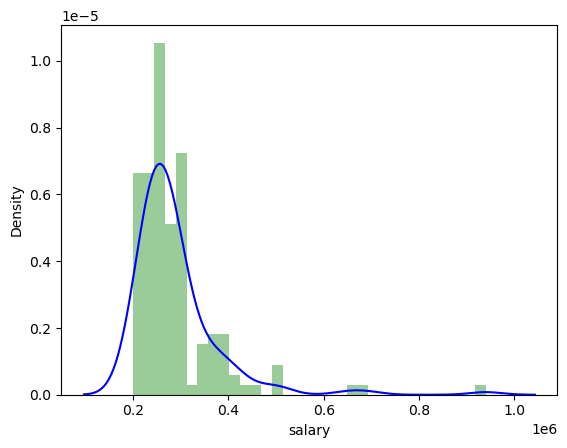

In [35]:
normaldist(dataset['salary'])

In [42]:
#Standard normal distribution
def stdnormdist(datcol):
    import seaborn as sns
    sample=datcol
    s_mean=sample.mean()
    s_std=sample.std()
    values=[i for i in datcol]
    z_score=[((j-s_mean)/s_std) for j in values]
    sns.distplot(z_score,kde=True,kde_kws={"color":"blue"},color="green")


C:\Users\Dayana\AppData\Local\Temp\ipykernel_6760\2979078599.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True,kde_kws={"color":"blue"},color="green")


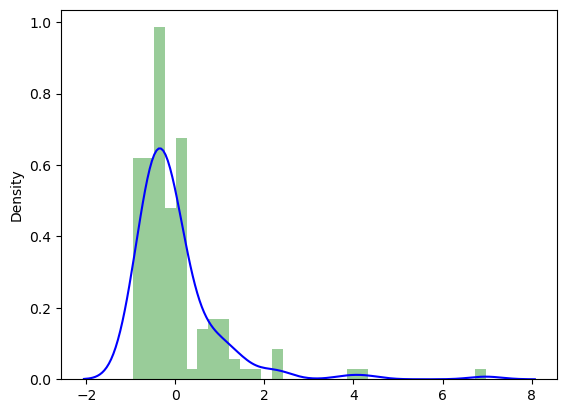

In [43]:
stdnormdist(dataset['salary'])

In [66]:
#10 What is the probability density function of the salary range from 700000 to 900000?

def normaldist(datcol,startr,endr):
    from scipy.stats import norm
    import seaborn as sns

    ax=sns.distplot(datcol,kde=True,kde_kws={"color":"blue"},color="green")
    
    sample=datcol
    s_mean=sample.mean()
    s_std=sample.std()
    dist=norm(s_mean,s_std)    

    values=[value for value in range(startr,endr)]
    probs=[dist.pdf(value) for value in values]
    prob=sum(probs)

    return prob

C:\Users\Dayana\AppData\Local\Temp\ipykernel_6760\2505096269.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(datcol,kde=True,kde_kws={"color":"blue"},color="green")


np.float64(5.377578376230696e-06)

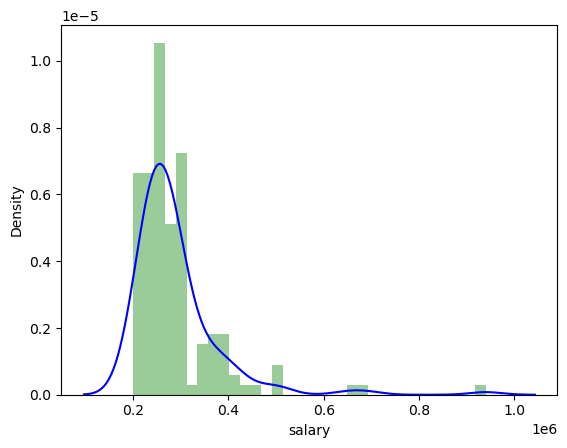

In [67]:
normaldist(dataset['salary'],700000,900000)

In [ ]:
#The probability density function of the salary range from 700000 to 900000 is 5.377578376230696e-06

In [46]:
#11 Test the similarity between the degree_t(Sci&Tech) 
#with respect to etest_p and mba_p at significance level of 5%.(Make decision using Hypothesis Testing)
#Same group & different condition(Paired Test OR Dependant Test)

#H0: There is no significant similarity between etest_p and mba_p
#H1: There is a significant similarity between etest_p and mba_p

from scipy.stats import ttest_rel
mbap=dataset[dataset['degree_t']=='Sci&Tech']['mba_p']
etestp=dataset[dataset['degree_t']=='Sci&Tech']['etest_p']
ttest_rel(mbap,etestp)

TtestResult(statistic=np.float64(-5.0049844583693615), pvalue=np.float64(5.517920600505392e-06), df=np.int64(58))

In [47]:
#p>0.05 ====> Accept H0(There is no significantt similarity between etest_p and mba_p

In [53]:
#12 Which parameter is highly correlated with salary?
dataset[['ssc_p','hsc_p','degree_p','mba_p','etest_p','salary']].corr()

,ssc_p,hsc_p,degree_p,mba_p,etest_p,salary
ssc_p,1.000000,0.511472,0.538404,0.388478,0.261993,0.035330
hsc_p,0.511472,1.000000,0.434206,0.354823,0.245113,0.076819
degree_p,0.538404,0.434206,1.000000,0.402364,0.224470,-0.019272
mba_p,0.388478,0.354823,0.402364,1.000000,0.218055,0.175013
etest_p,0.261993,0.245113,0.224470,0.218055,1.000000,0.178307
salary,0.035330,0.076819,-0.019272,0.175013,0.178307,1.000000


In [54]:
#mba and entrance marks are positively correlated with salary 

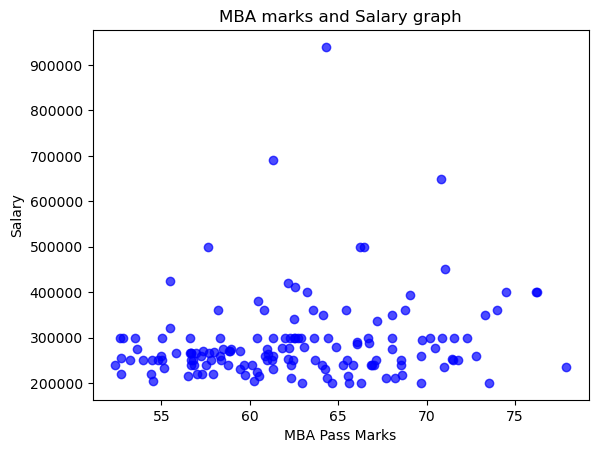

In [58]:
#13 Plot any useful graph and explain it
import matplotlib.pyplot as plt
x=dataset['mba_p']
y=dataset['salary']
plt.scatter(x,y,color='blue',alpha=0.7)

plt.title("MBA marks and Salary graph")
plt.xlabel("MBA Pass Marks")
plt.ylabel("Salary")
plt.show()